# Plots

Below we plot many of the Softtorch functions for different modes and softnesses to give an idea of how they look like.
All functions are designed to be soft when used on inputs in an interval [0,1] when setting default softness of 1.0. 
When inputs in other ranges are used, softness can be scaled accordingly, e.g. on inputs distributed in the interval [0, 100] a softness of 100.0 should result in a soft behavior.

In [1]:
import softtorch as st
import torch
from plot_utils import configure_plots, plot, plot_softness_sweep


configure_plots()

## Sigmoid-based

In [2]:
modes = ["smooth", "c0", "c1", "c2"]
fss_modes = ["c0", "c1", "c2"]  # fast_soft_sort doesn't support smooth

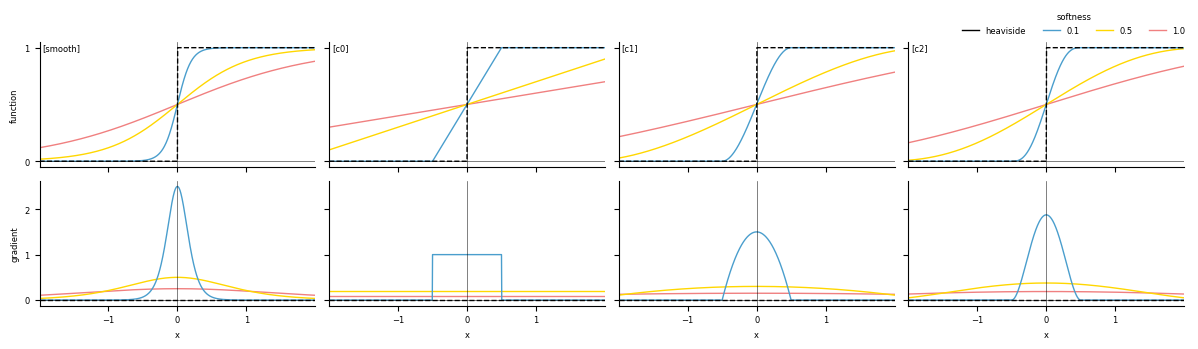

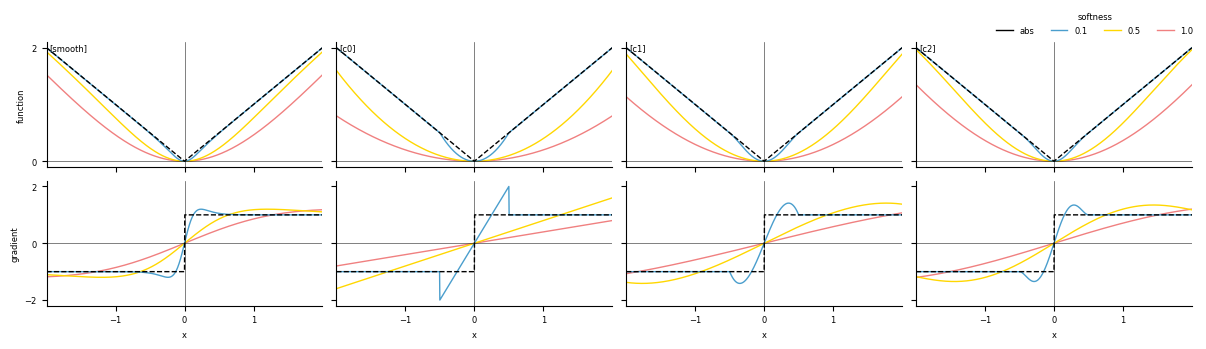

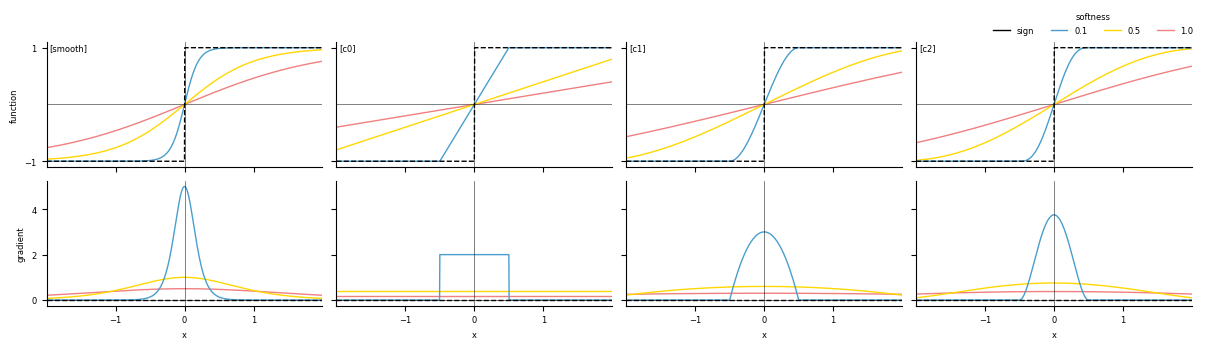

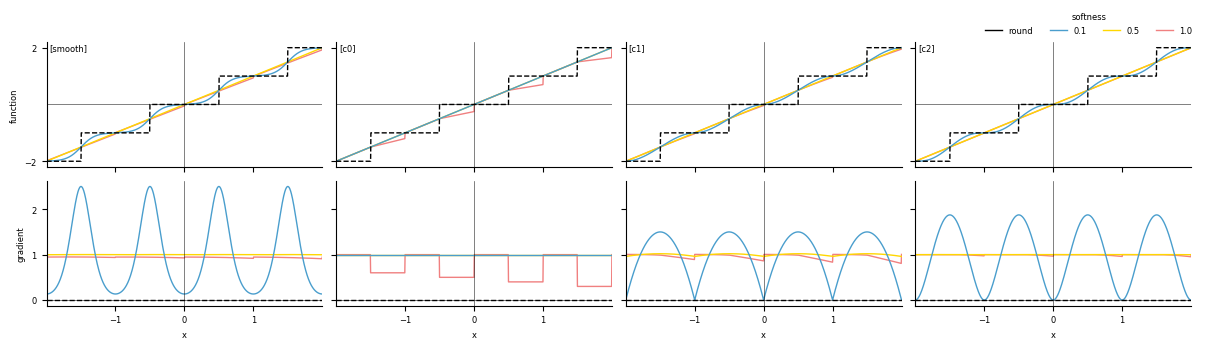

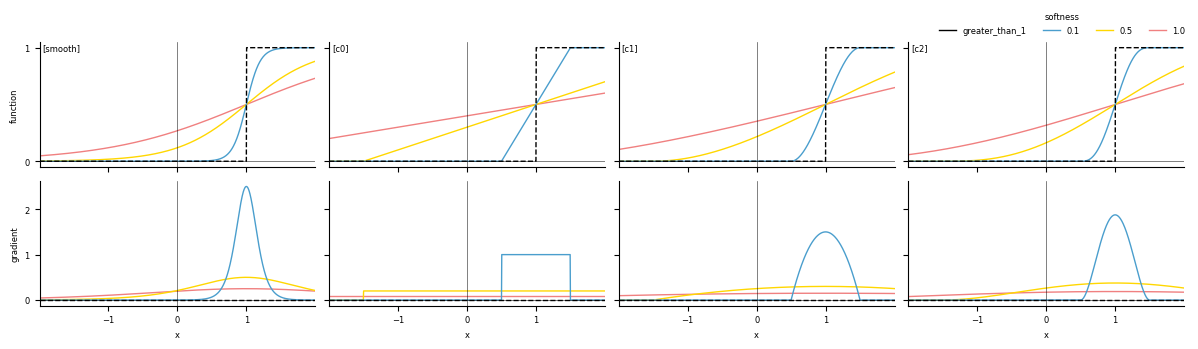

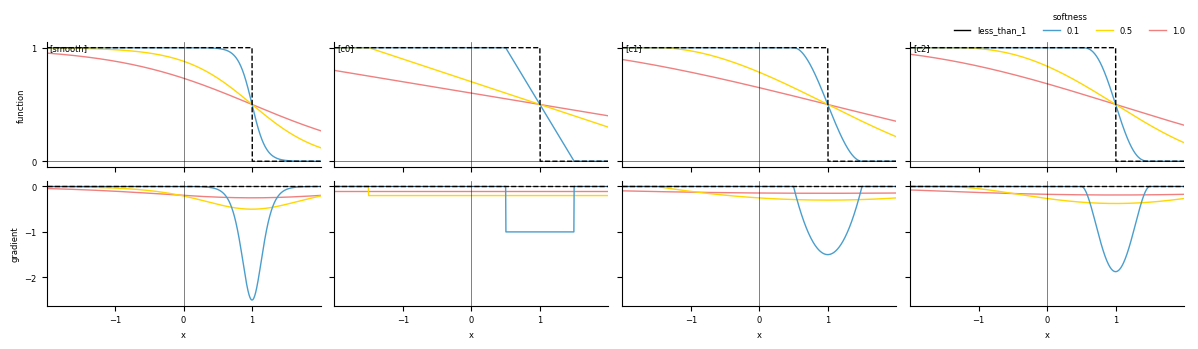

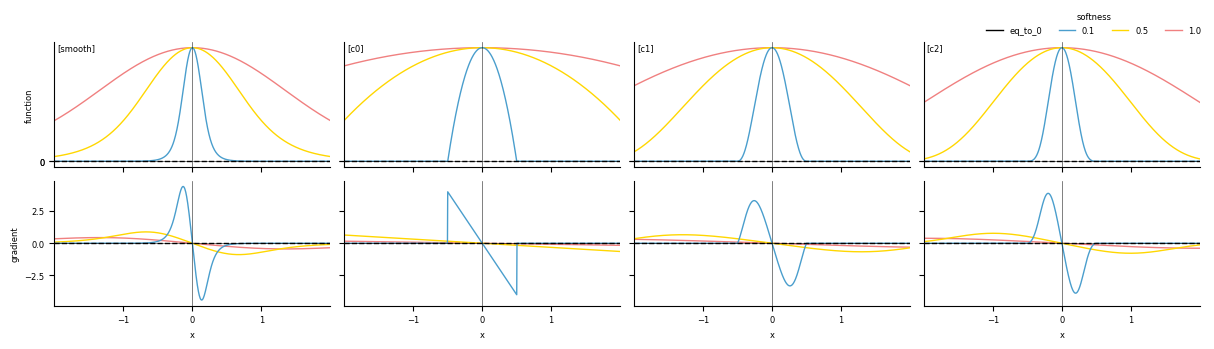

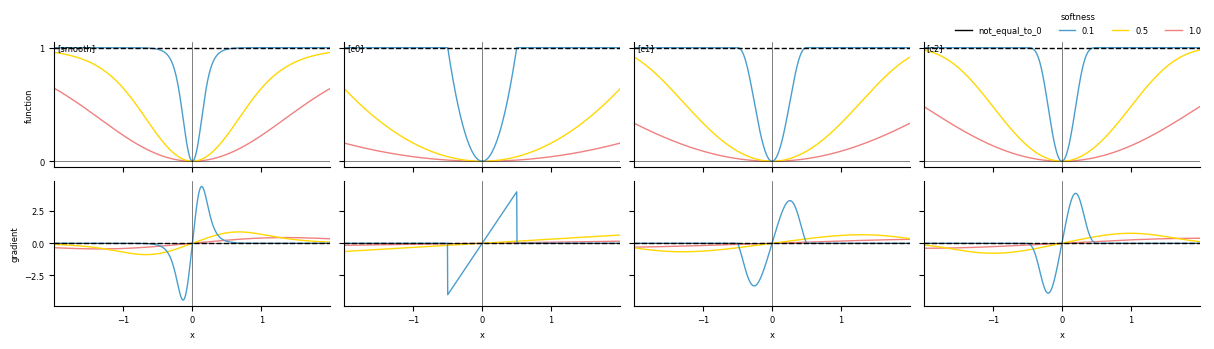

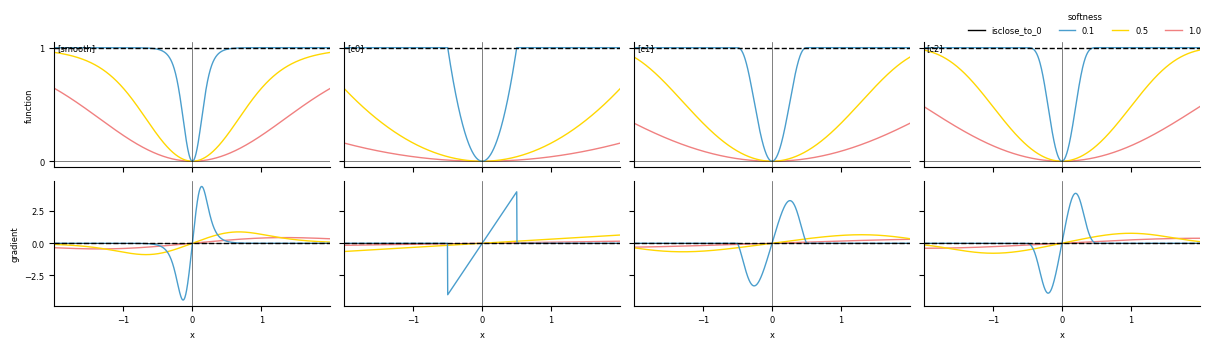

In [3]:
def greater_than_1(x, **kwargs):
    return st.greater(x, torch.tensor(1.0), **kwargs)


def less_than_1(x, **kwargs):
    return st.less(x, torch.tensor(1.0), **kwargs)


def eq_to_0(x, **kwargs):
    return st.eq(x, torch.tensor(0.0), **kwargs)


def not_equal_to_0(x, **kwargs):
    return st.not_equal(x, torch.tensor(0.0), **kwargs)


def isclose_to_0(x, **kwargs):
    return st.not_equal(x, torch.tensor(0.0), **kwargs)


plot(st.heaviside, modes=modes)
plot(st.abs, modes=modes)
plot(st.sign, modes=modes)
plot(st.round, modes=modes)
plot(greater_than_1, modes=modes)
plot(less_than_1, modes=modes)
plot(eq_to_0, modes=modes)
plot(not_equal_to_0, modes=modes)
plot(isclose_to_0, modes=modes)

## Softplus-based

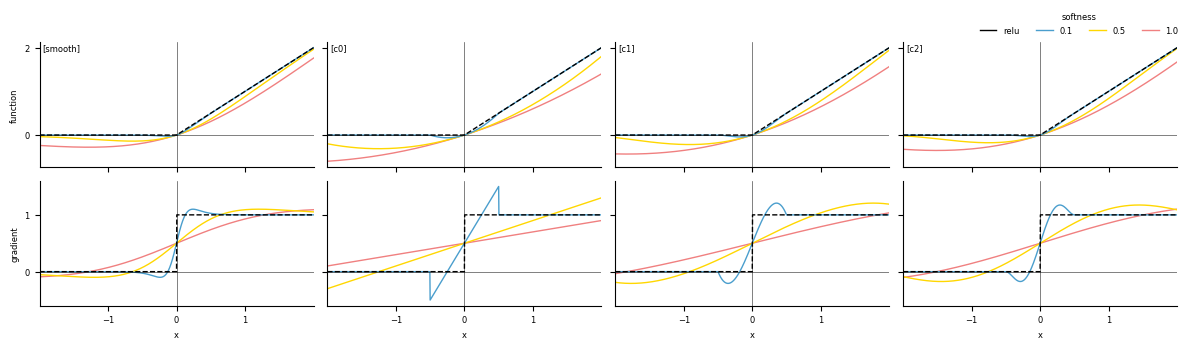

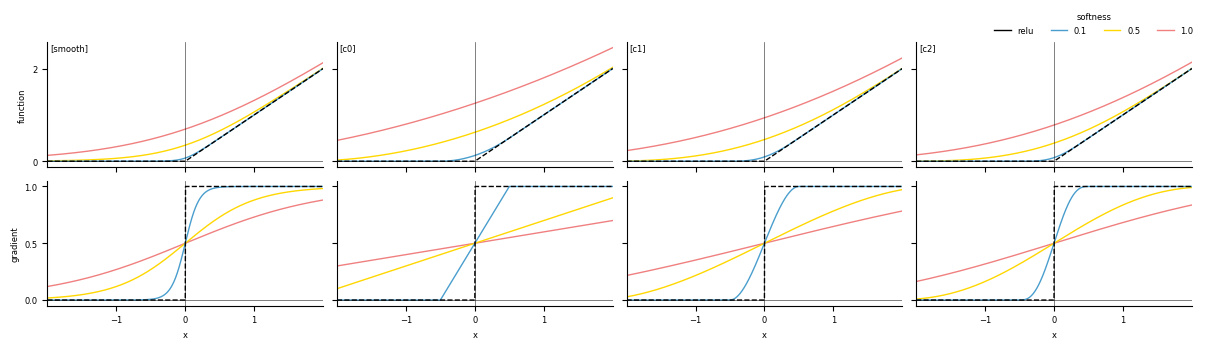

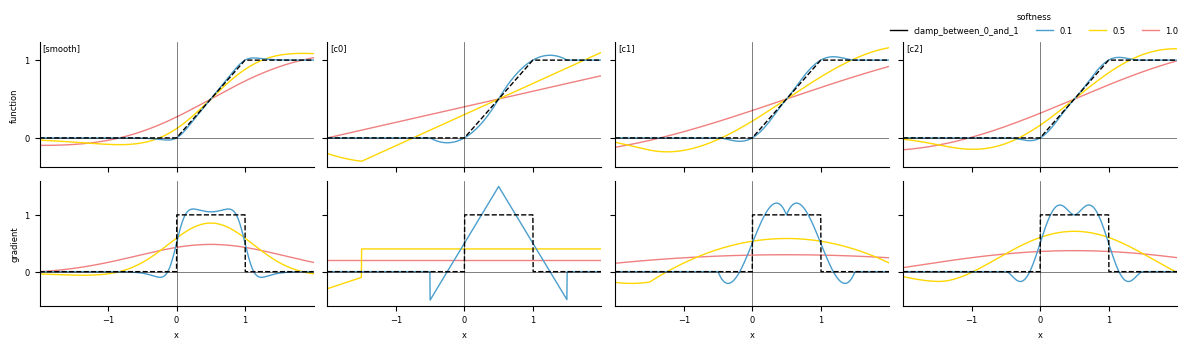

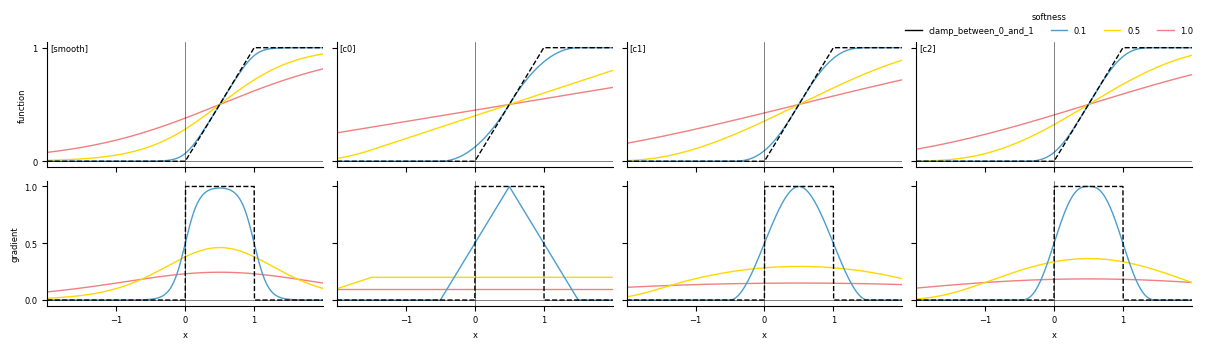

In [4]:
def clamp_between_0_and_1(x, **kwargs):
    return st.clamp(x, torch.tensor(0.0), torch.tensor(1.0), **kwargs)


plot(st.relu, modes=modes, gated=True)
plot(st.relu, modes=modes, gated=False)
plot(clamp_between_0_and_1, modes=modes, gated=True)
plot(clamp_between_0_and_1, modes=modes, gated=False)

## Simplex-projection / optimal transport based

Sort (softsort):


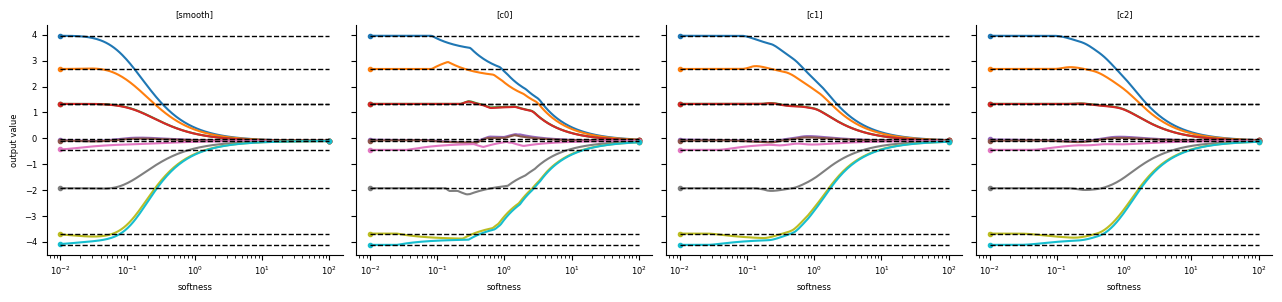

Sort (neuralsort):


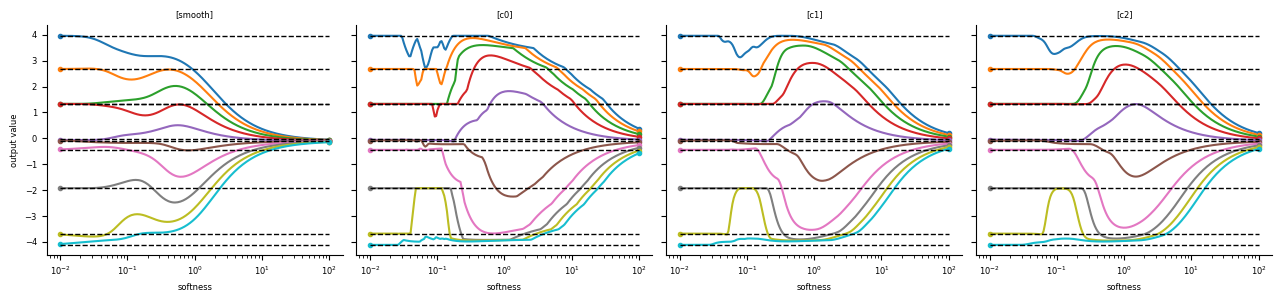

Sort (fast_soft_sort):


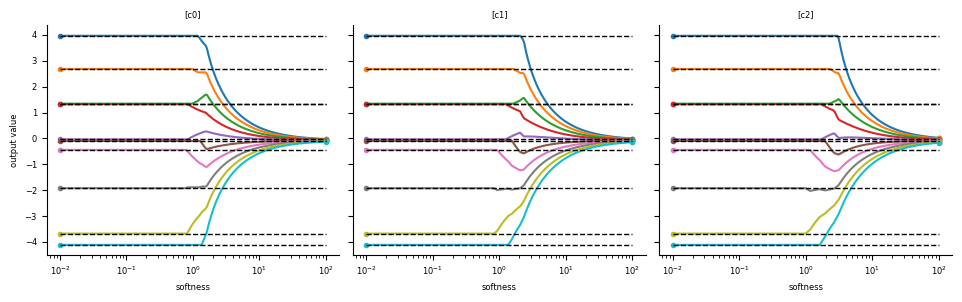

Sort (ot):


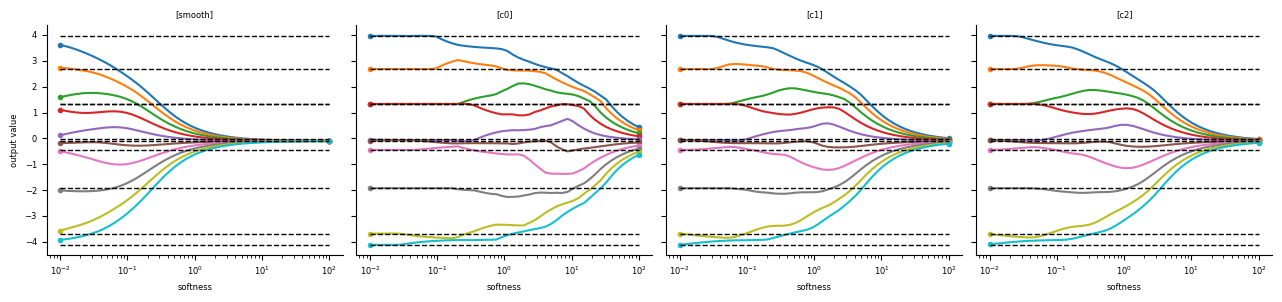

Sort (sorting_network):


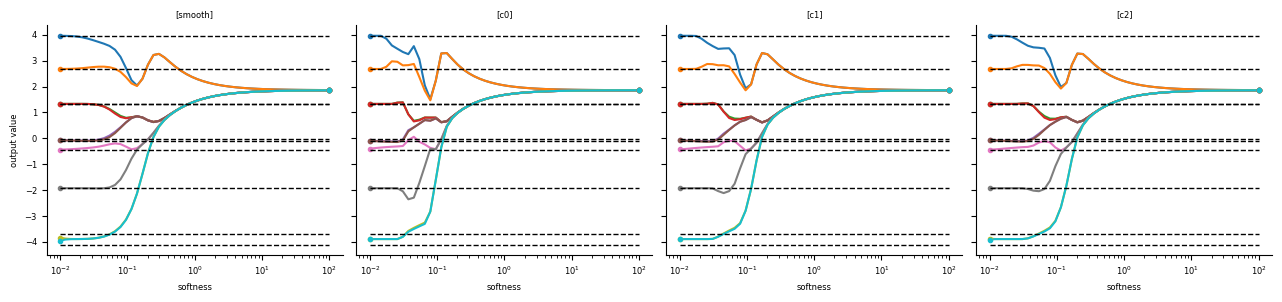

Rank (softsort):


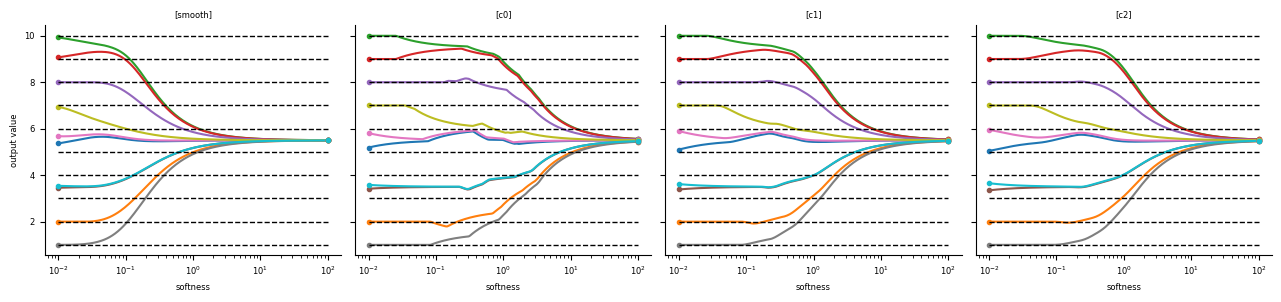

Rank (neuralsort):


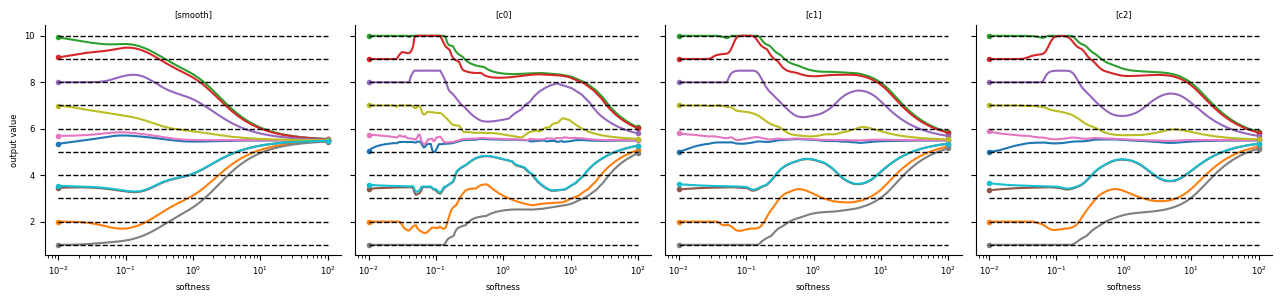

Rank (fast_soft_sort):


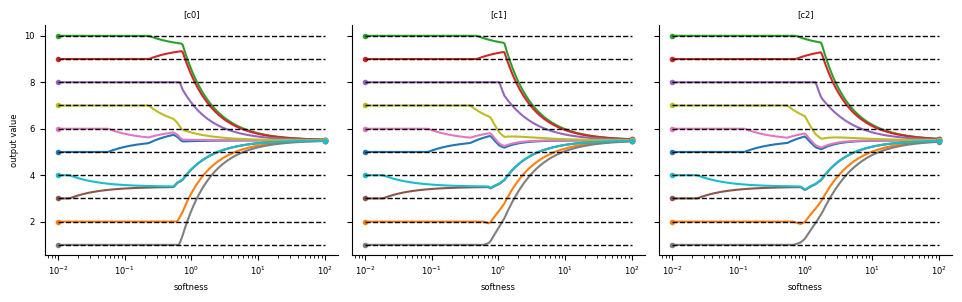

Rank (ot):


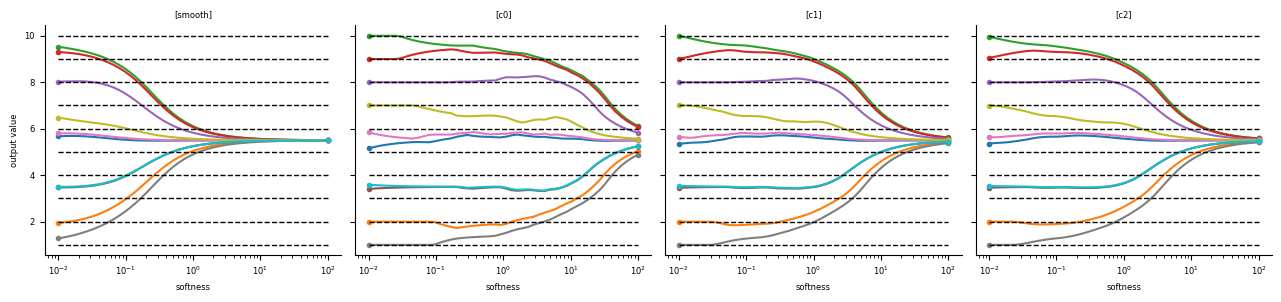

Rank (sorting_network):


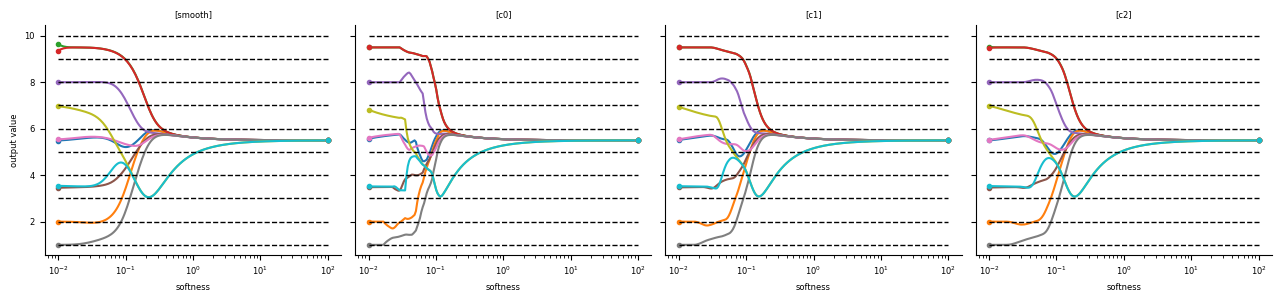

(<Figure size 1280x300 with 4 Axes>,
 array([<Axes: title={'center': '[smooth]'}, xlabel='softness', ylabel='output value'>,
        <Axes: title={'center': '[c0]'}, xlabel='softness'>,
        <Axes: title={'center': '[c1]'}, xlabel='softness'>,
        <Axes: title={'center': '[c2]'}, xlabel='softness'>], dtype=object))

In [5]:
torch.manual_seed(0)
x = torch.rand(10) * 10 - 5

print("Sort (softsort):")
plot_softness_sweep(st.sort, modes=modes, method="softsort", descending=True, x=x)
print("Sort (neuralsort):")
plot_softness_sweep(st.sort, modes=modes, method="neuralsort", descending=True, x=x)
print("Sort (fast_soft_sort):")
plot_softness_sweep(
    st.sort, modes=fss_modes, method="fast_soft_sort", descending=True, x=x
)
print("Sort (ot):")
plot_softness_sweep(
    st.sort, modes=modes, method="ot", descending=True, x=x, num_softness=50
)
print("Sort (sorting_network):")
plot_softness_sweep(
    st.sort,
    modes=modes,
    method="sorting_network",
    descending=True,
    x=x,
    num_softness=50,
)

print("Rank (softsort):")
plot_softness_sweep(st.rank, modes=modes, method="softsort", descending=True, x=x)
print("Rank (neuralsort):")
plot_softness_sweep(st.rank, modes=modes, method="neuralsort", descending=True, x=x)
print("Rank (fast_soft_sort):")
plot_softness_sweep(
    st.rank, modes=fss_modes, method="fast_soft_sort", descending=True, x=x
)
print("Rank (ot):")
plot_softness_sweep(
    st.rank, modes=modes, method="ot", descending=True, x=x, num_softness=50
)
print("Rank (sorting_network):")
plot_softness_sweep(
    st.rank, modes=modes, method="sorting_network", descending=True, x=x
)

In [6]:
values = [-1.0, 0.5, 1.0]


def _augment(x):
    return torch.stack([x] + [torch.full_like(x, v) for v in values], dim=-1)


def soft_max(x, **kwargs):
    return st.max(_augment(x), dim=-1, **kwargs).values


def soft_max_st(x, **kwargs):
    return st.max_st(_augment(x), dim=-1, **kwargs).values


def soft_min(x, **kwargs):
    return st.min(_augment(x), dim=-1, **kwargs).values


def soft_median(x, **kwargs):
    return st.median(_augment(x), dim=-1, **kwargs).values


def soft_quantile(x, **kwargs):
    return st.quantile(_augment(x), q=torch.tensor(0.2), dim=-1, **kwargs)


def soft_argquantile(x, **kwargs):
    return st.argquantile(_augment(x), q=torch.tensor(0.2), dim=-1, **kwargs)[..., 0]


def soft_sort(x, **kwargs):
    return st.sort(_augment(x), **kwargs).values[..., 2]


def soft_argsort(x, **kwargs):
    return st.argsort(_augment(x), **kwargs)[..., 0, 0]


def soft_sort_st(x, **kwargs):
    return st.sort_st(_augment(x), **kwargs).values[..., 0]


def soft_top_k(x, **kwargs):
    return st.topk(_augment(x), k=2, **kwargs).values[..., 0]


def soft_rank(x, **kwargs):
    return st.rank(_augment(x), dim=-1, **kwargs)[..., 0]

Max


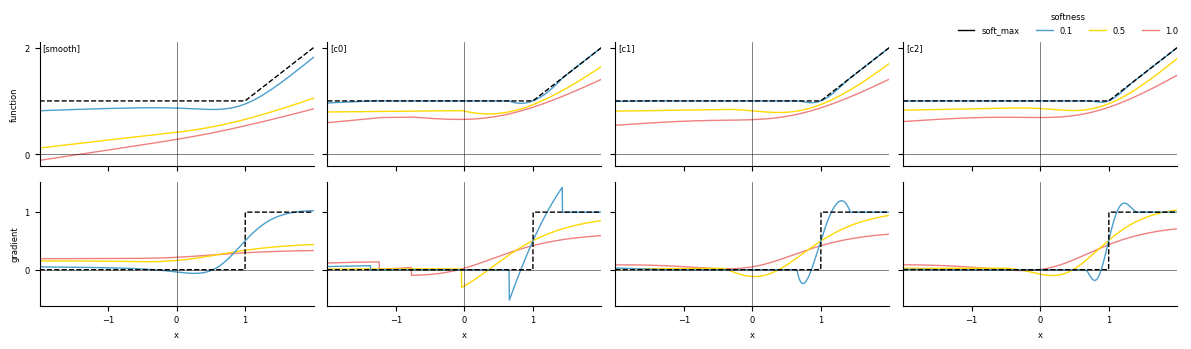

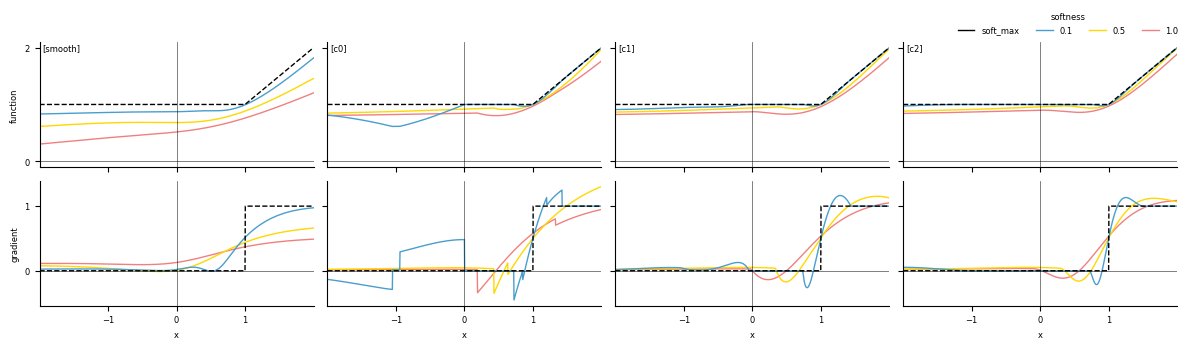

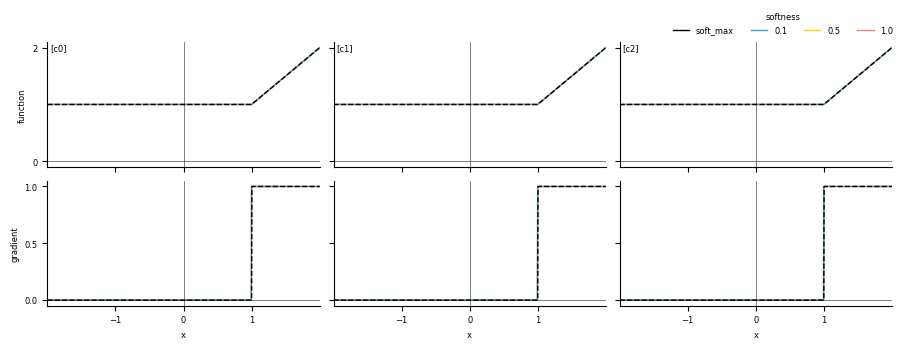

Max_st


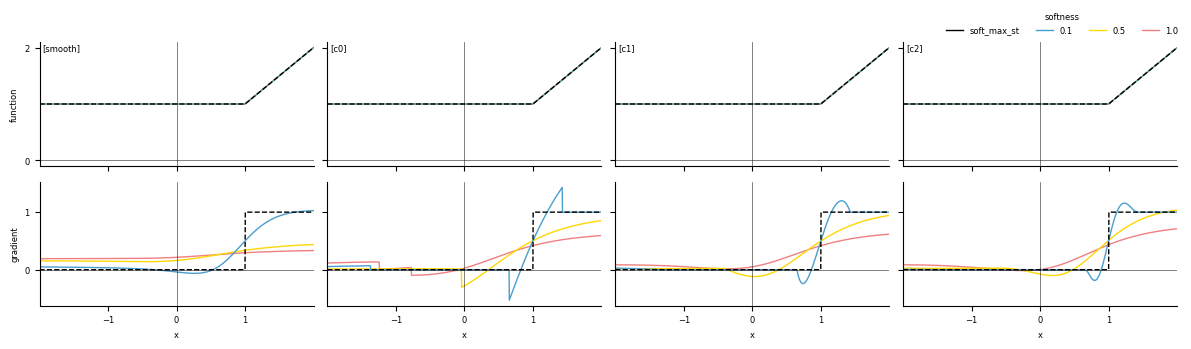

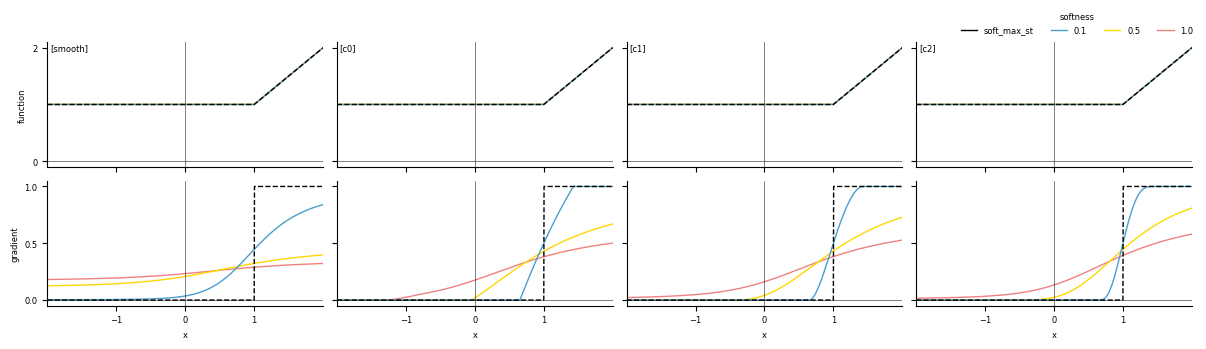

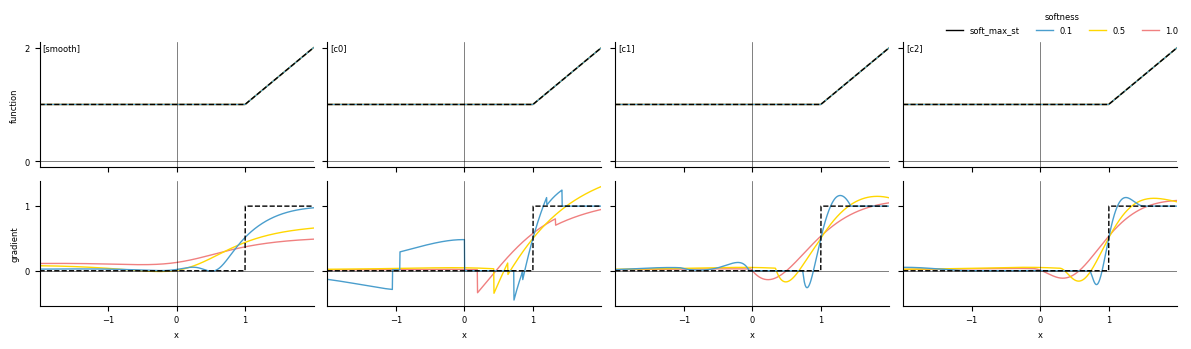

In [7]:
print("Max")
plot(soft_max, modes=modes, method="softsort")
plot(soft_max, modes=modes, method="neuralsort")
plot(soft_max, modes=fss_modes, method="fast_soft_sort")

print("Max_st")
plot(soft_max_st, modes=modes, method="softsort", gated_grad=True)
plot(soft_max_st, modes=modes, method="softsort", gated_grad=False)
plot(soft_max_st, modes=modes, method="neuralsort")

Min


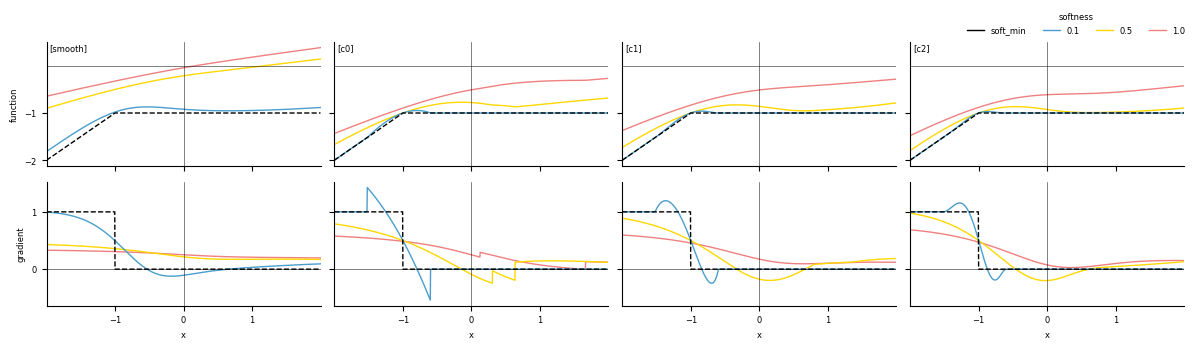

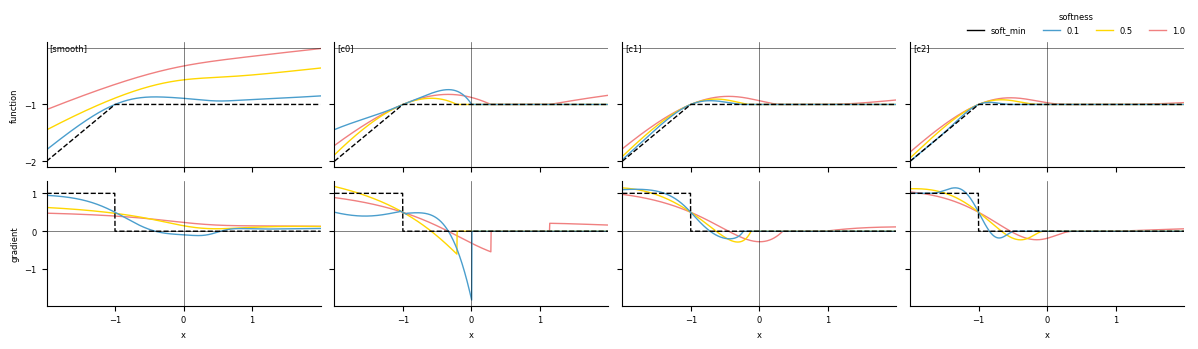

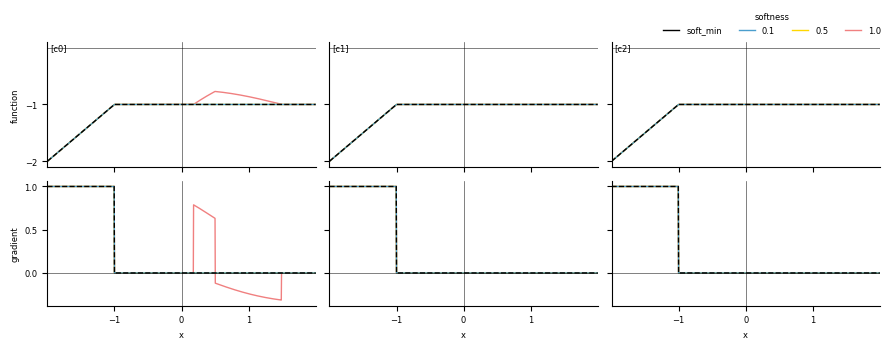

Top K


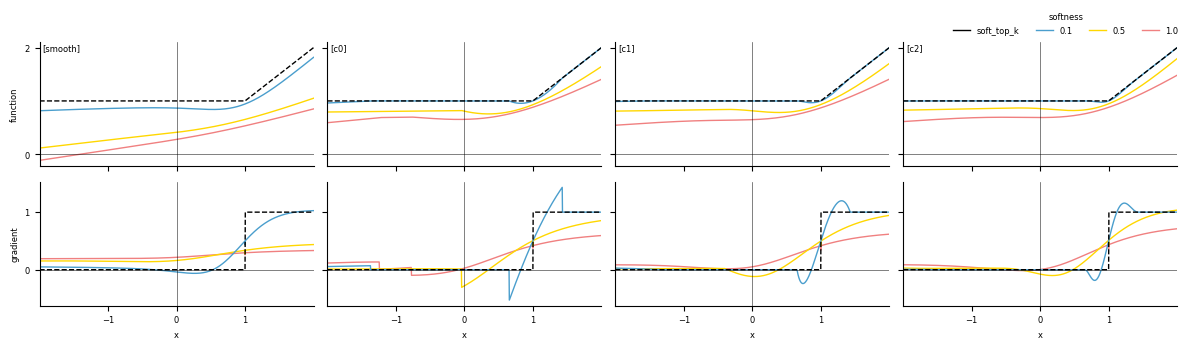

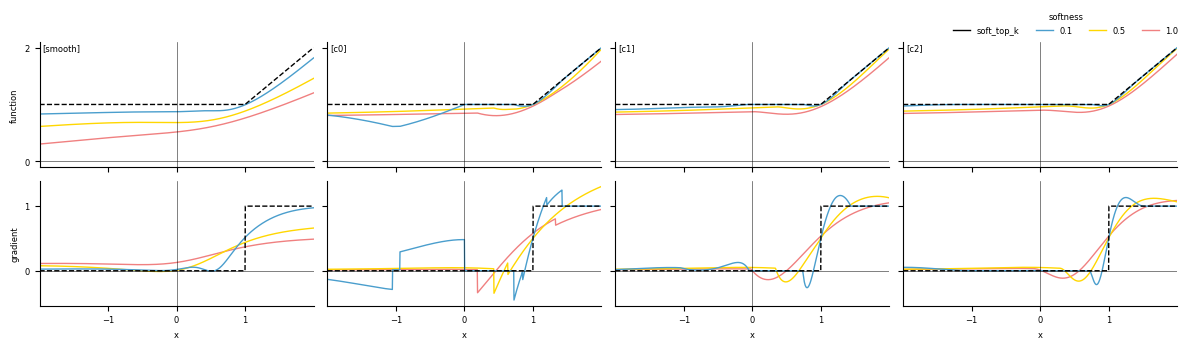

In [8]:
print("Min")
plot(soft_min, modes=modes, method="softsort")
plot(soft_min, modes=modes, method="neuralsort")
plot(soft_min, modes=fss_modes, method="fast_soft_sort")

print("Top K")
plot(soft_top_k, modes=modes, method="softsort")
plot(soft_top_k, modes=modes, method="neuralsort")

Sort


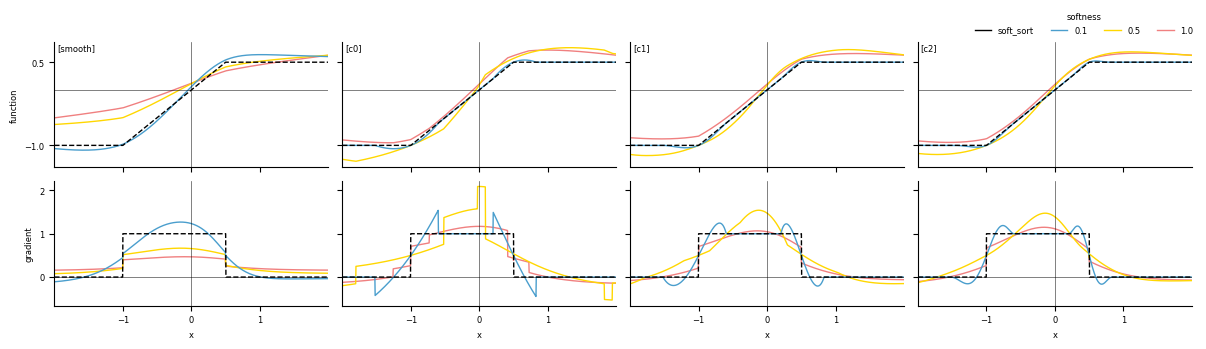

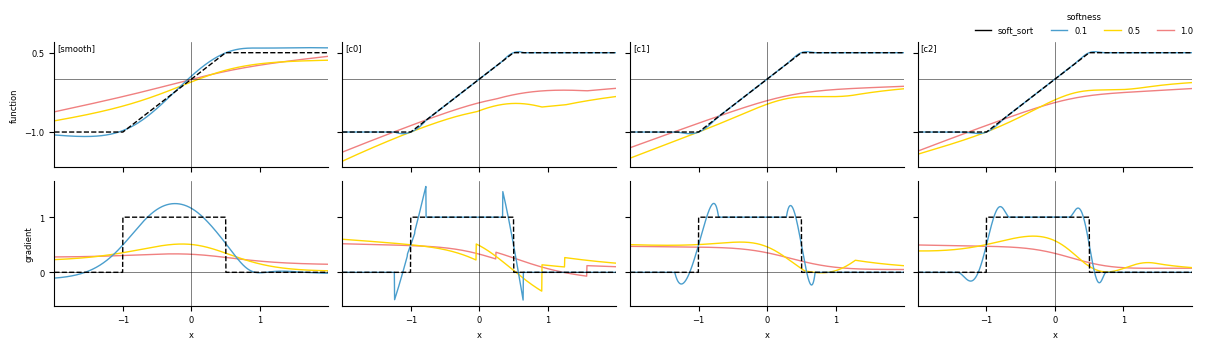

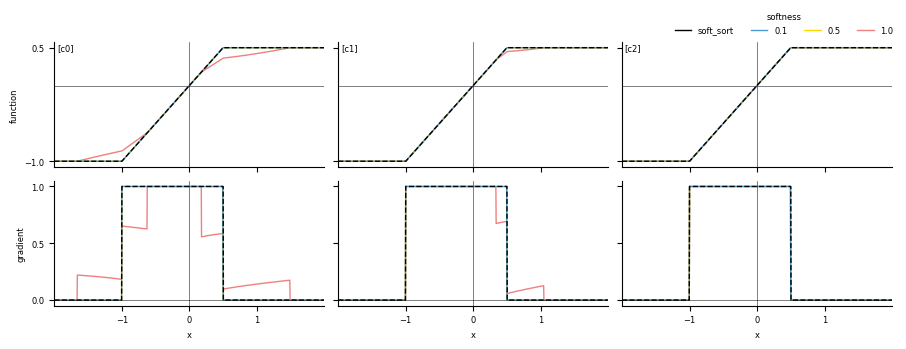

Argsort


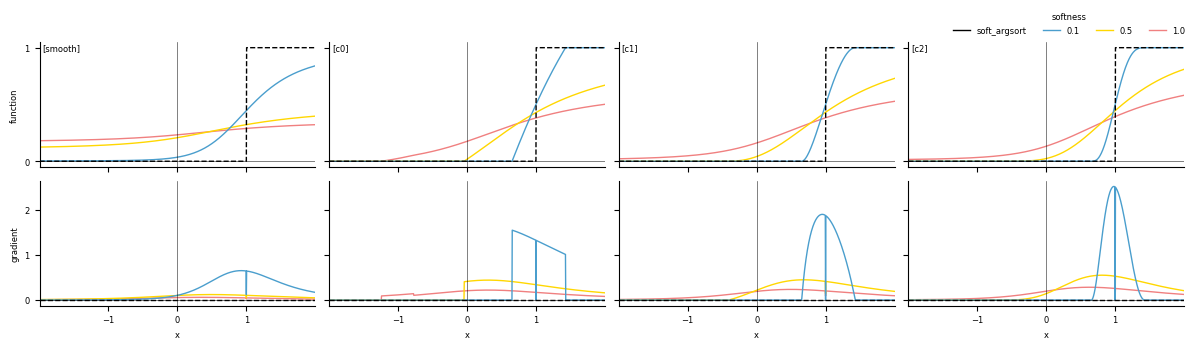

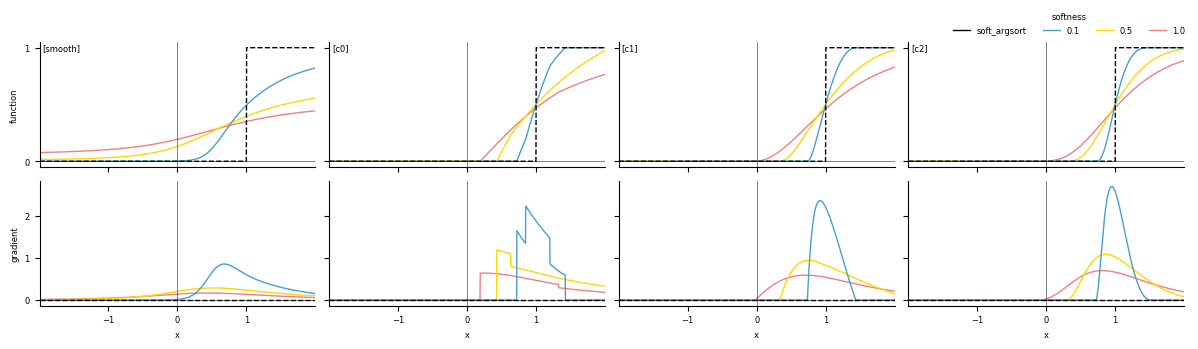

In [9]:
print("Sort")
plot(soft_sort, modes=modes, method="softsort", descending=True)
plot(soft_sort, modes=modes, method="neuralsort", descending=True)
plot(soft_sort, modes=fss_modes, method="fast_soft_sort", descending=True)

print("Argsort")
plot(soft_argsort, modes=modes, method="softsort", descending=True)
plot(soft_argsort, modes=modes, method="neuralsort", descending=True)

Sort_st


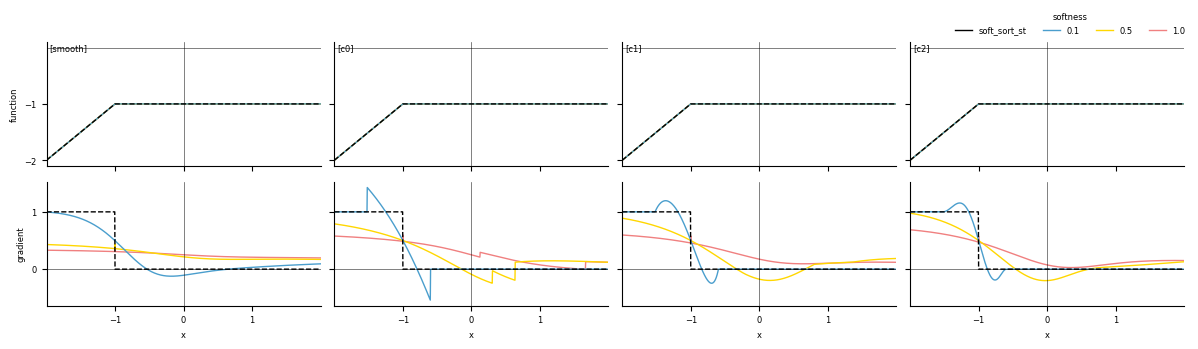

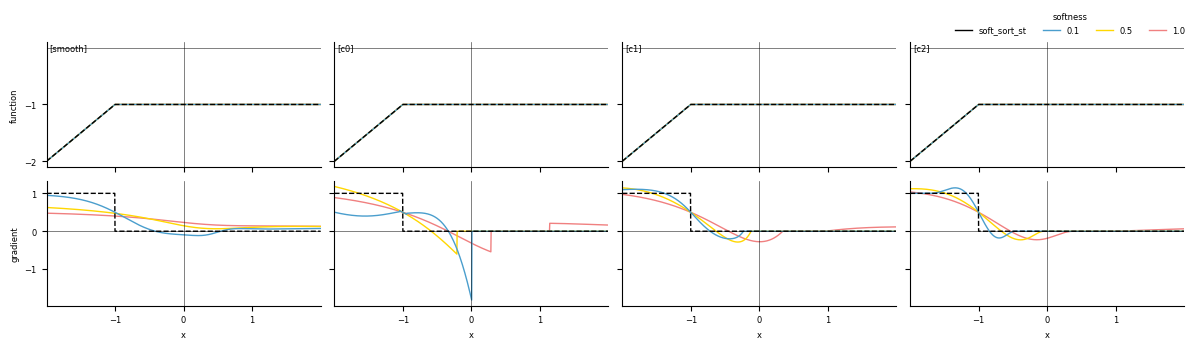

Quantile


/home/local_apaulus/Projects/softops/softtorch/src/softtorch/functions.py:805: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  q = torch.tensor(q, dtype=x.dtype, device=x.device)


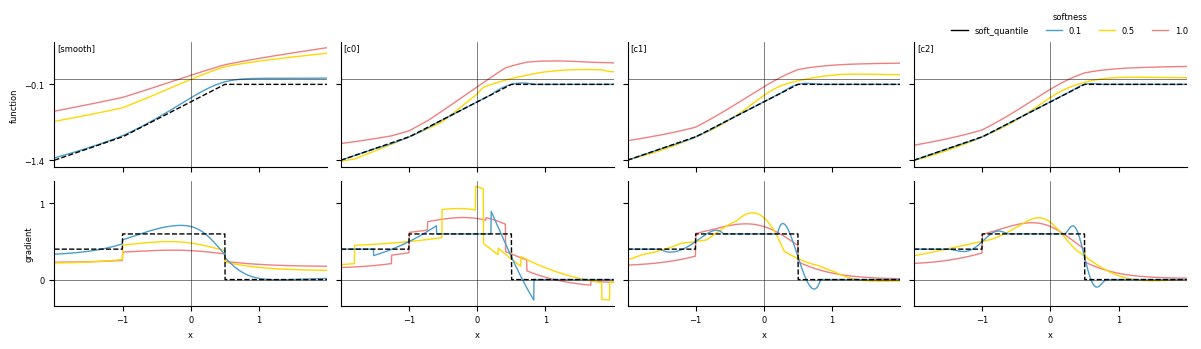

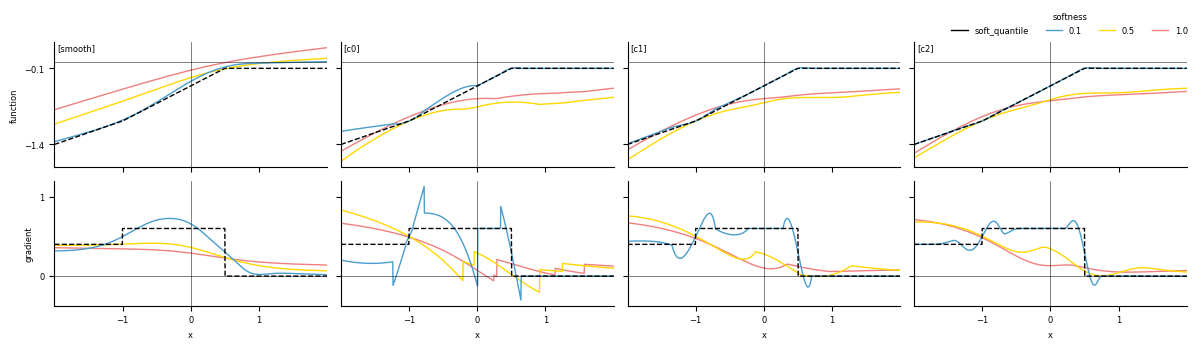

In [10]:
print("Sort_st")
plot(soft_sort_st, modes=modes, method="softsort")
plot(soft_sort_st, modes=modes, method="neuralsort")

print("Quantile")
plot(soft_quantile, modes=modes, method="softsort")
plot(soft_quantile, modes=modes, method="neuralsort")

Argquantile


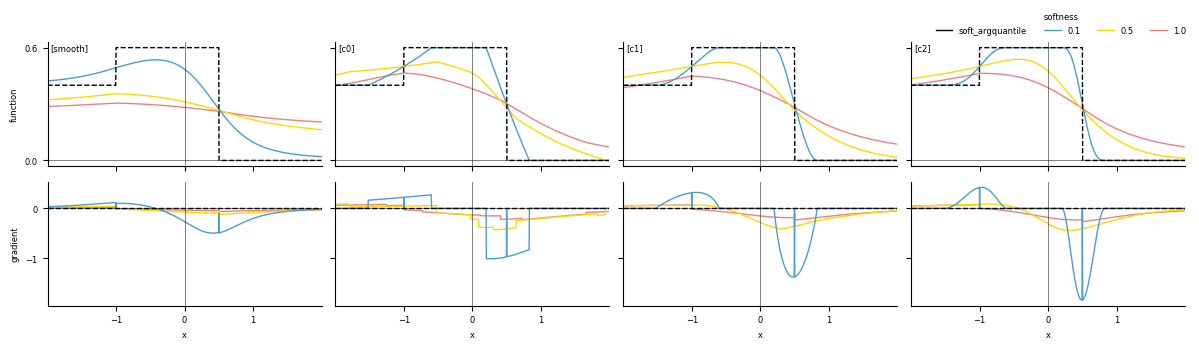

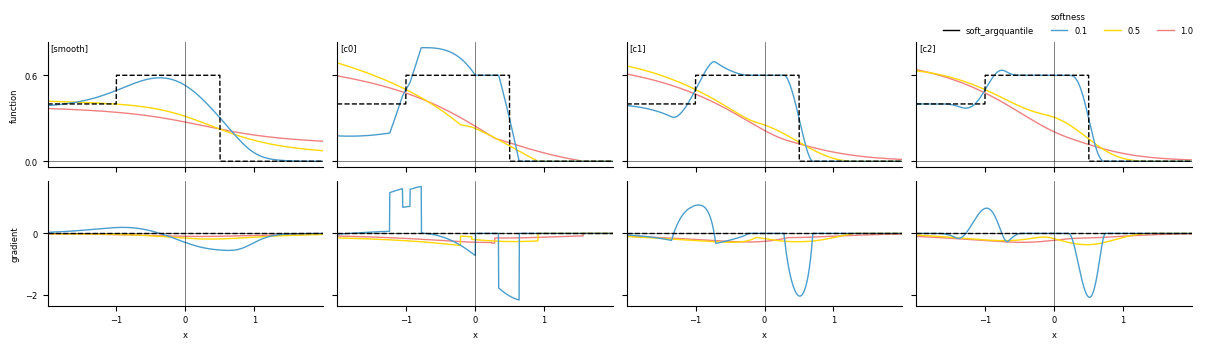

Median


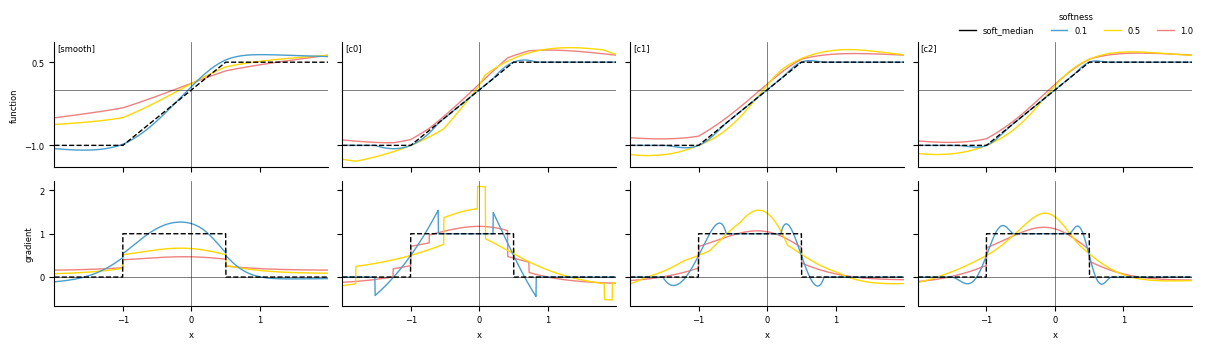

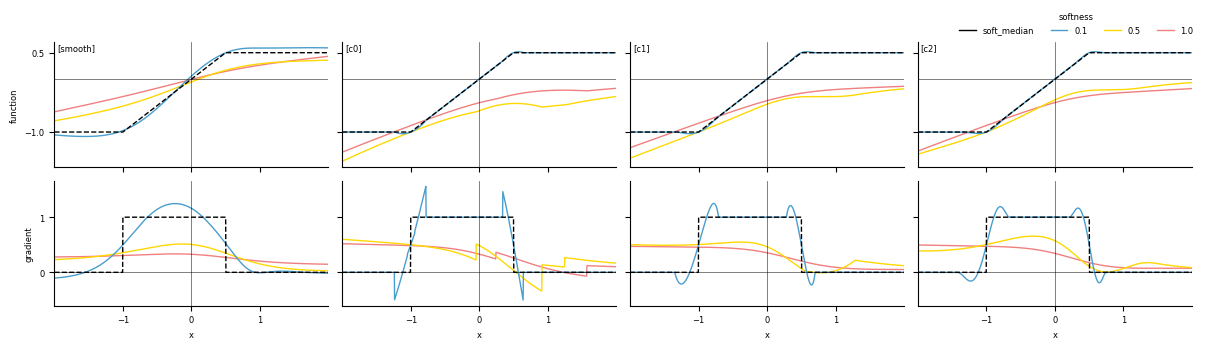

Rank


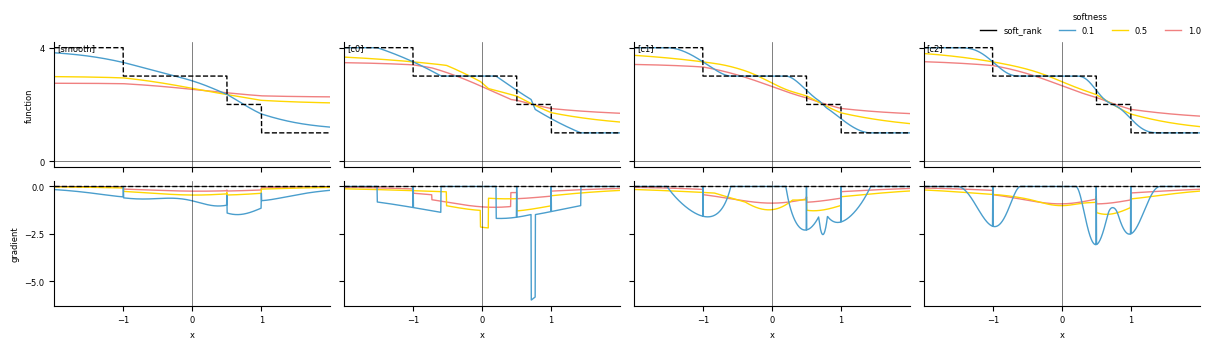

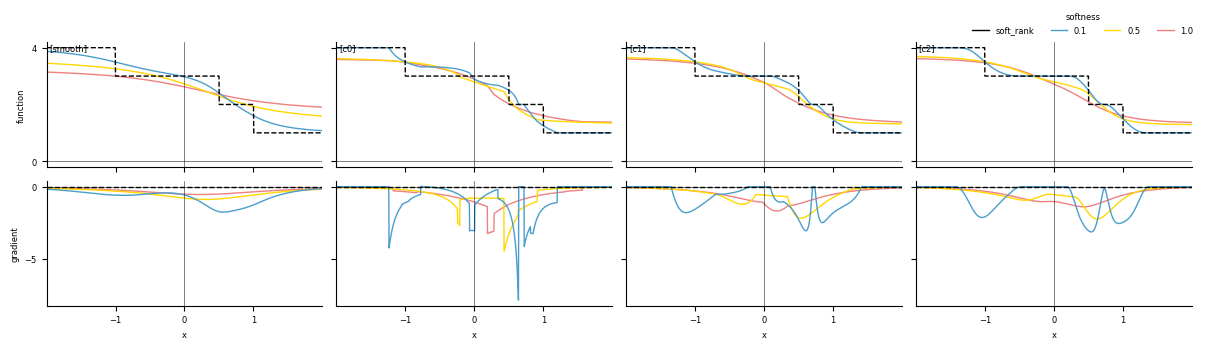

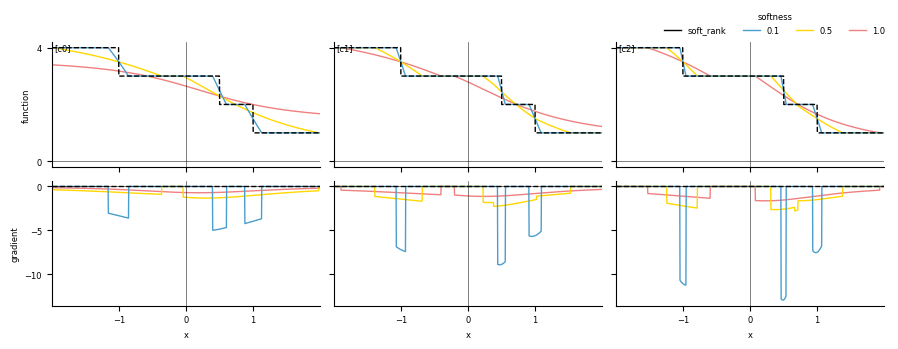

In [11]:
print("Argquantile")
plot(soft_argquantile, modes=modes, method="softsort")
plot(soft_argquantile, modes=modes, method="neuralsort")

print("Median")
plot(soft_median, modes=modes, method="softsort")
plot(soft_median, modes=modes, method="neuralsort")

print("Rank")
plot(soft_rank, modes=modes, method="softsort")
plot(soft_rank, modes=modes, method="neuralsort")
plot(soft_rank, modes=fss_modes, method="fast_soft_sort")